Module importing

In [1]:
import sys
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import scipy.signal as signal
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader,TensorDataset,random_split,SubsetRandomSampler, ConcatDataset

sys.path.append(r'D:/ppg_project/code/model_build/my_tool/model')
from multiResUnet_1D import MultiResUnet
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool')
from model_builder import k_fold_training
from performance import performance
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool/data_load')
from ppg_labeled_load import PPGDataset

Data prepairing

In [6]:
full_dataset = PPGDataset('D:\\ppg_project\\Data\\data_train', label_list = "AR")
test_dataset = PPGDataset('D:\\ppg_project\\Data\\data_test', label_list = "AR")
print(f"Number of data in train dataset: {len(full_dataset)}")
print(f"Number of data in test dataset: {len(test_dataset)}")


Number of data in train dataset: 333
Number of data in test dataset: 84


Training

In [8]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Đang sử dụng GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("Đang sử dụng CPU.")

Đang sử dụng GPU: NVIDIA GeForce RTX 4090


In [24]:
# ==============================
# 4. Định nghĩa cấu hình và khởi tạo Model
# ==============================
para = {
    "Input channel": 1,
    "Number class": 1,
    "Serie length": 800,
    "Filter nums": [32, 64, 128],
    "Block kernel": [3, 5, 7],
    "Pooling kernel": [2, 2, 2],
    "Transpose kernel": [2, 2, 2],
    "Respath length": 4,
    "Filter rate": [1.67, 0.333, 0.5],
}
model = MultiResUnet(para)

print(model)


# ==============================
# 5. Huấn luyện mô hình
# ==============================
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.L1Loss()  # Dùng L1Loss cho bài toán hồi quy tín hiệu

builder = k_fold_training(full_dataset, 1, criterion=criterion)
builder.training(model, device, optimizer, num_epochs=1000, batch=16, visualize=1)


MultiResUnet(
  (encoder_layer): ModuleList(
    (0): Multiresblock(
      (shortcut): Conv1d_batchnorm(
        (conv1): Conv1d(1, 132, kernel_size=(1,), stride=(1,), padding=same)
        (batchnorm): BatchNorm1d(132, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (conv_1): Conv1d_batchnorm(
        (conv1): Conv1d(1, 89, kernel_size=(3,), stride=(1,), padding=same)
        (batchnorm): BatchNorm1d(89, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (conv_2): Conv1d_batchnorm(
        (conv1): Conv1d(89, 17, kernel_size=(5,), stride=(1,), padding=same)
        (batchnorm): BatchNorm1d(17, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (conv_3): Conv1d_batchnorm(
        (conv1): Conv1d(17, 26, kernel_size=(7,), stride=(1,), padding=same)
        (batchnorm): BatchNorm1d(26, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (batch_norm1): BatchNorm1d(132, eps=1e-05, 

Performance

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_11448\2692554754.py:2: SyntaxWarning: invalid escape sequence '\p'
  test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")


Max loss:  1.0
Mean loss:  0.6275595
Min loss:  0.0
Number of test:  84


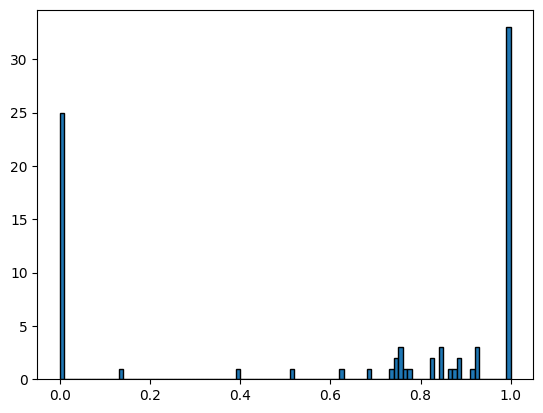

0.8425


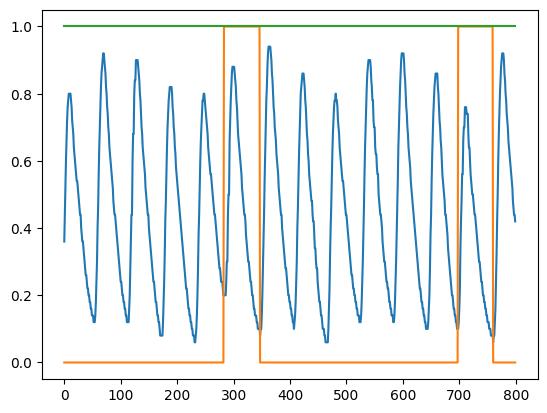

0.0


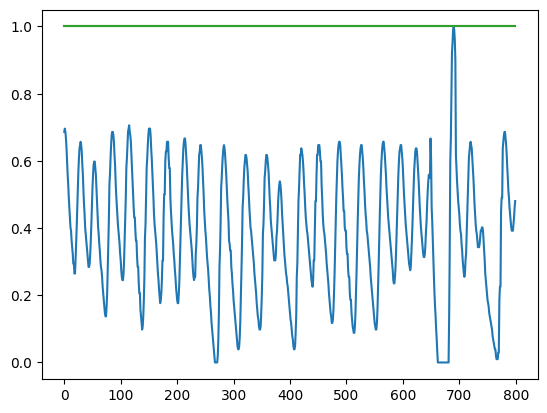

0.0


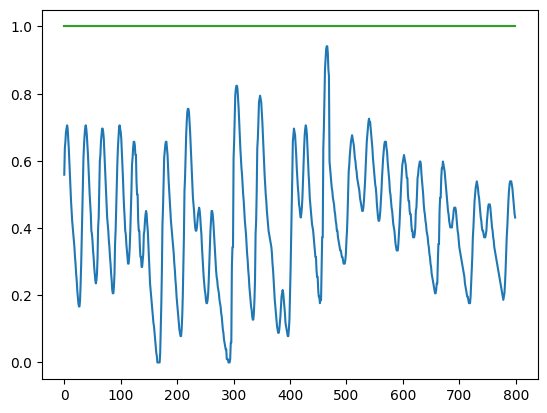

1.0


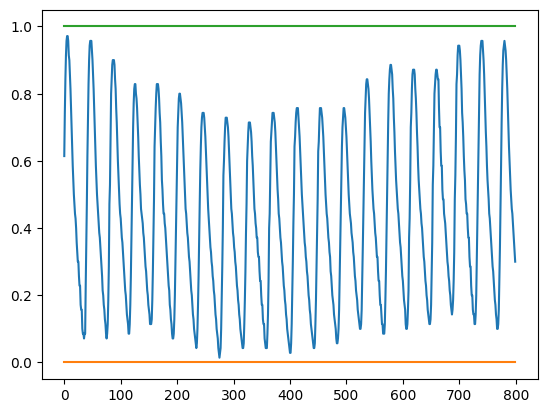

1.0


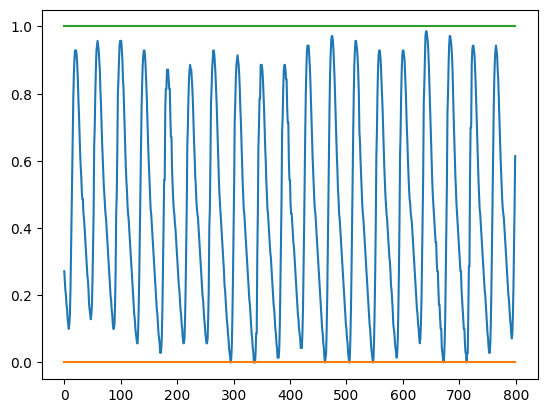

1.0


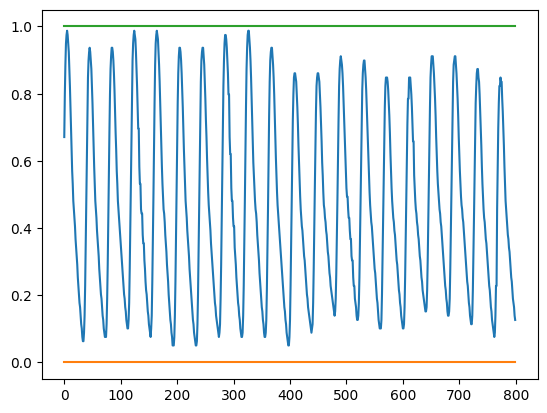

1.0


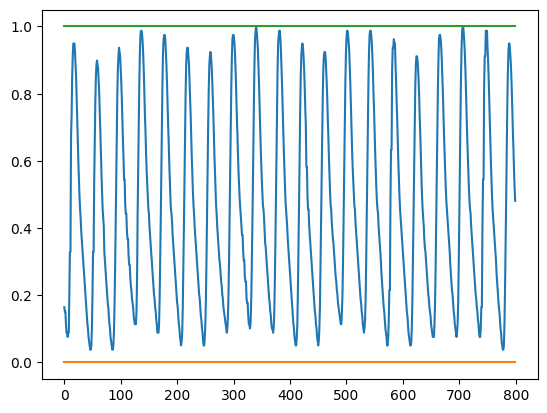

1.0


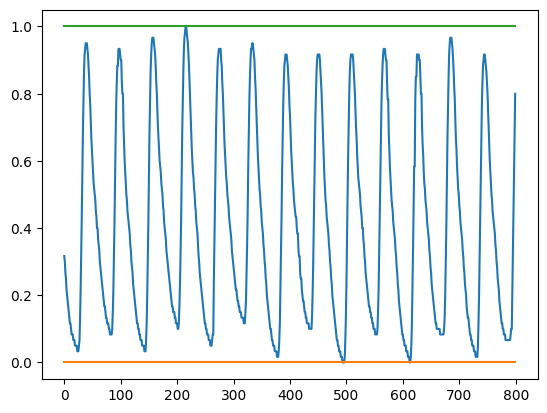

1.0


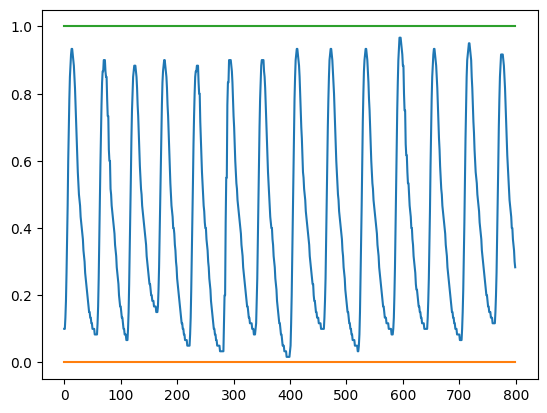

1.0


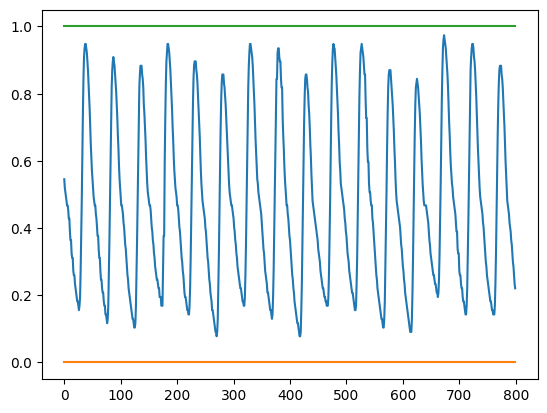

1.0


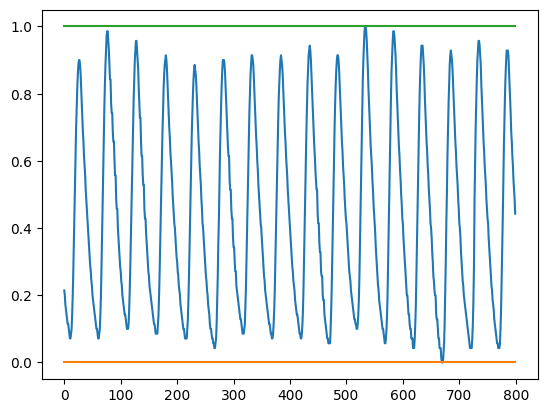

1.0


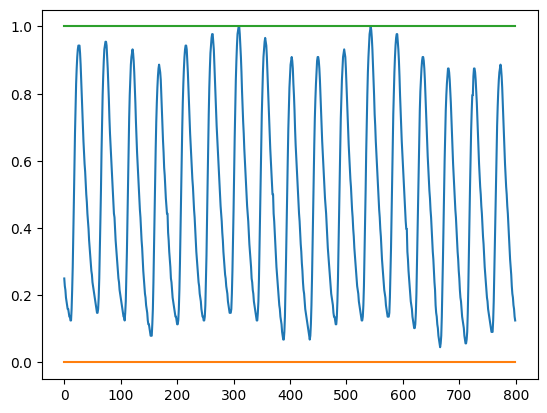

0.82


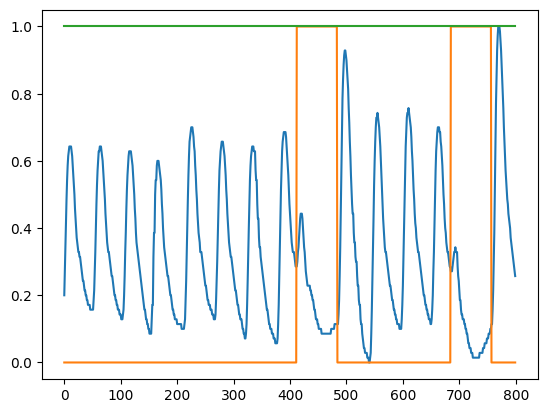

1.0


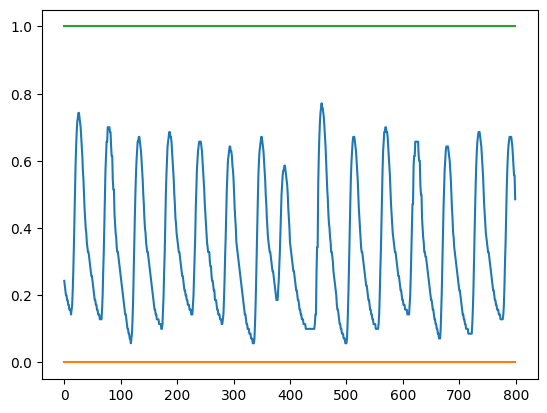

0.92375


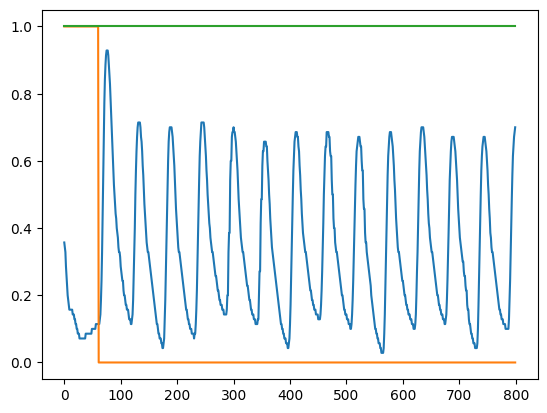

1.0


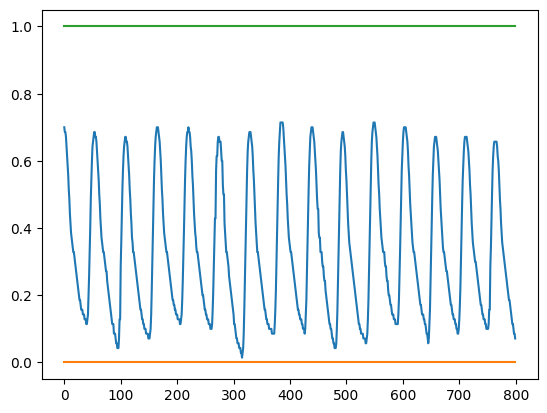

0.00125


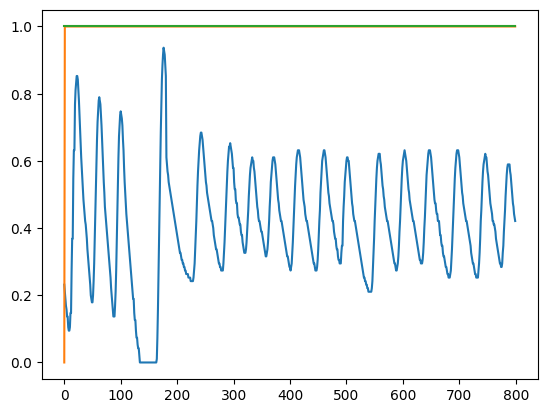

0.0


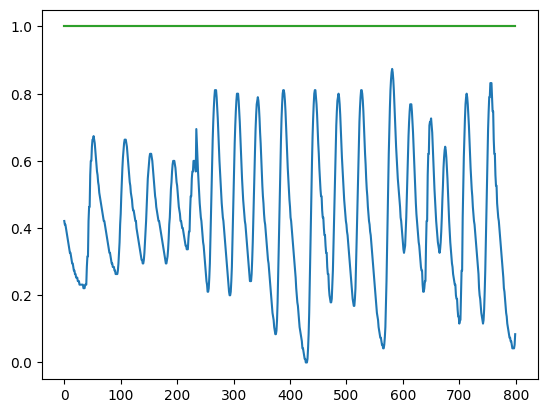

0.0


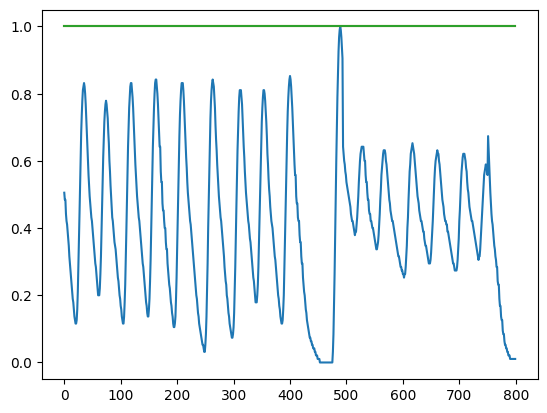

0.0


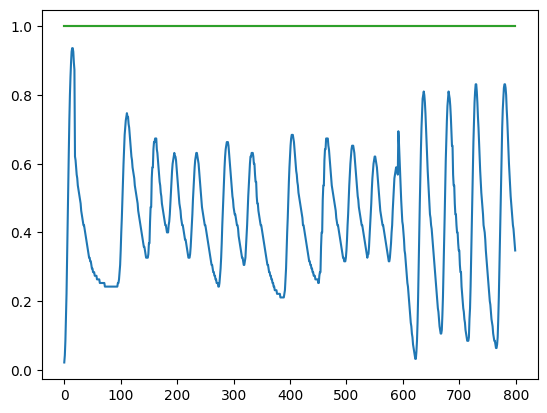

0.0


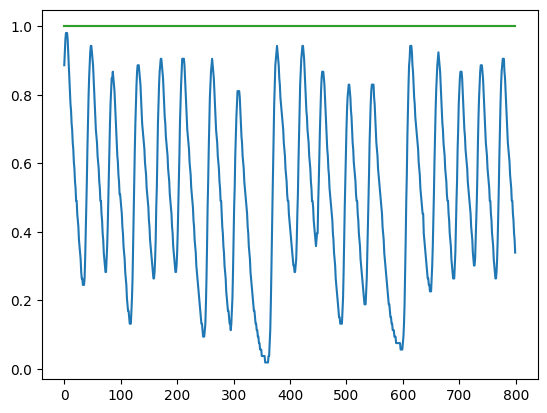

1.0


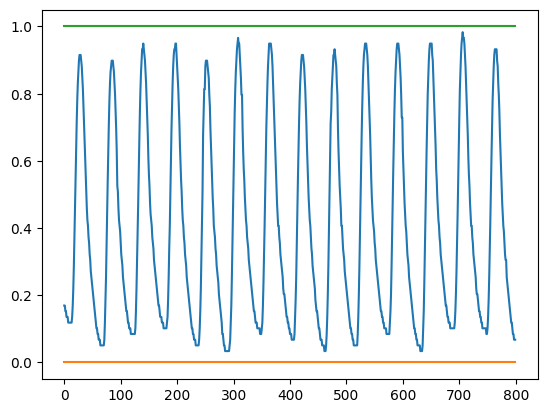

1.0


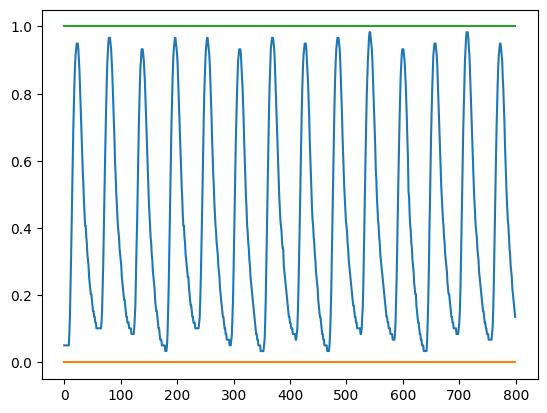

1.0


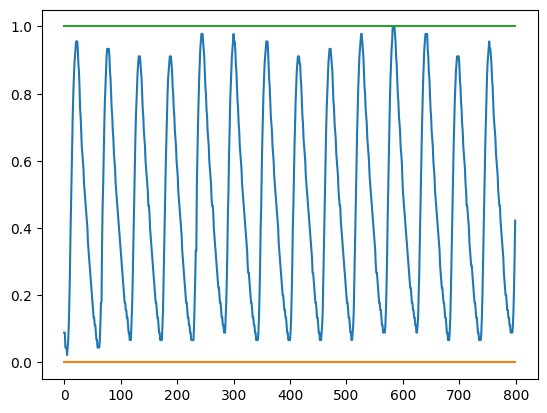

1.0


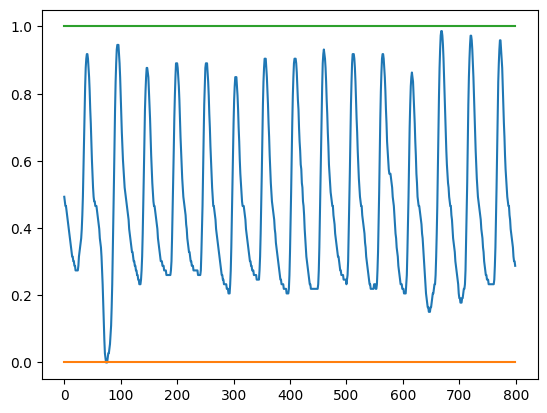

1.0


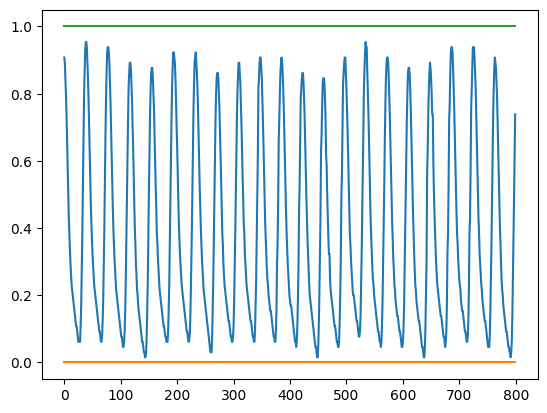

0.0


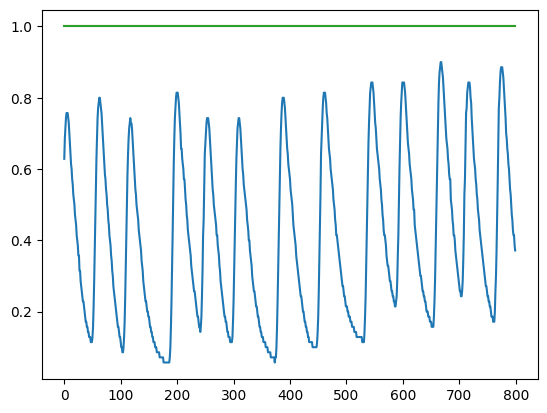

1.0


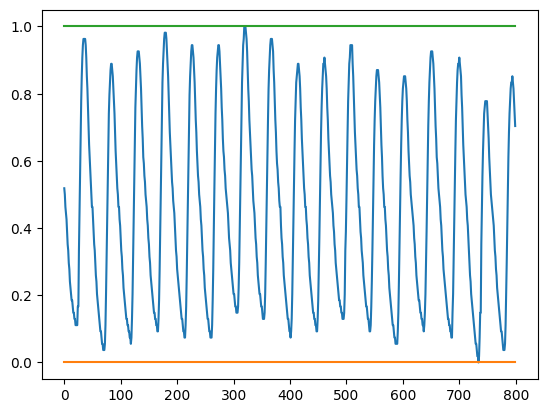

1.0


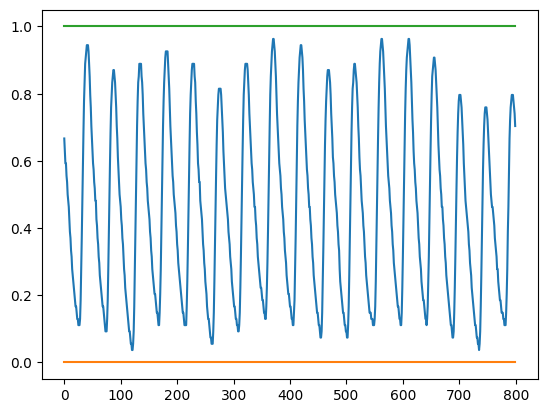

0.13125


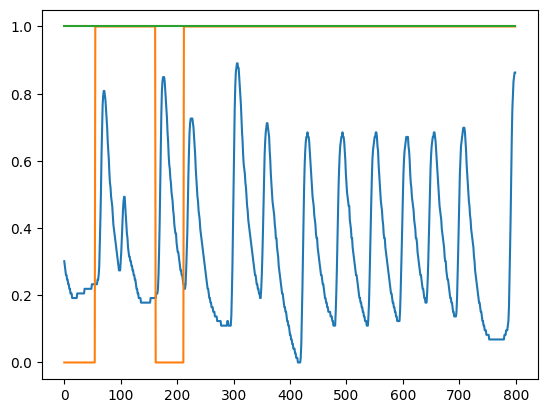

1.0


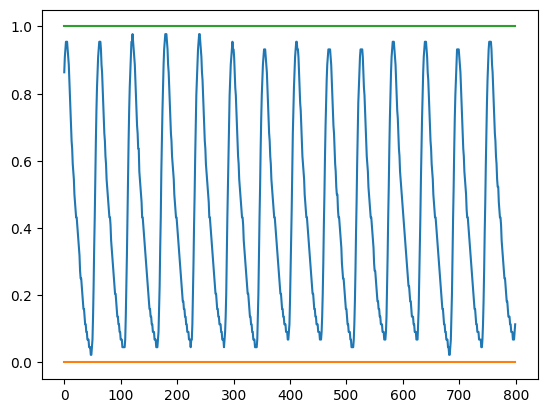

1.0


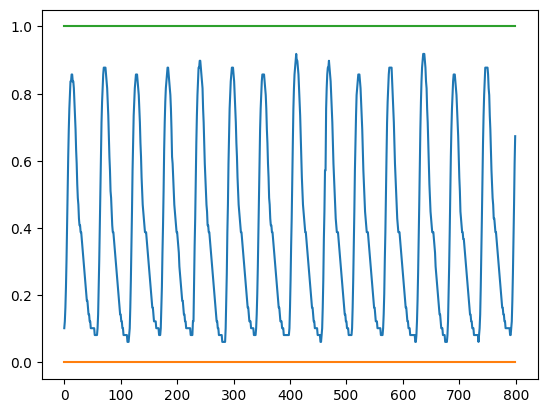

1.0


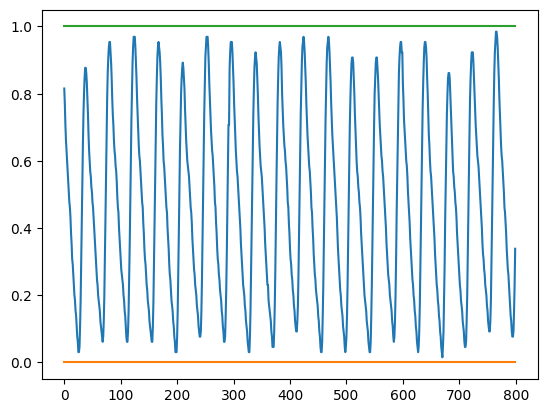

1.0


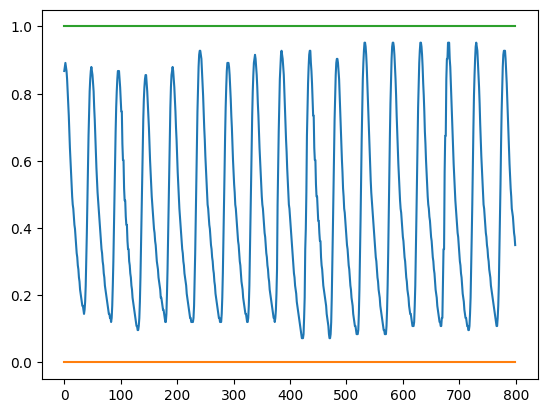

1.0


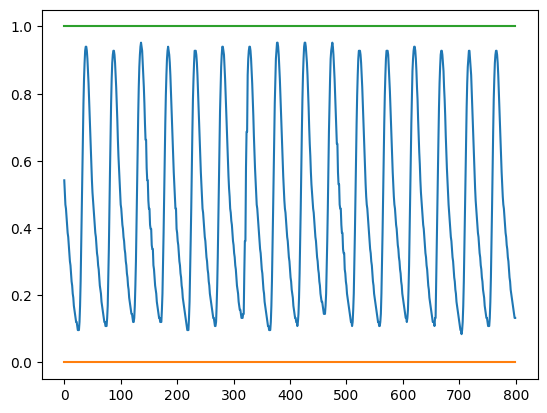

1.0


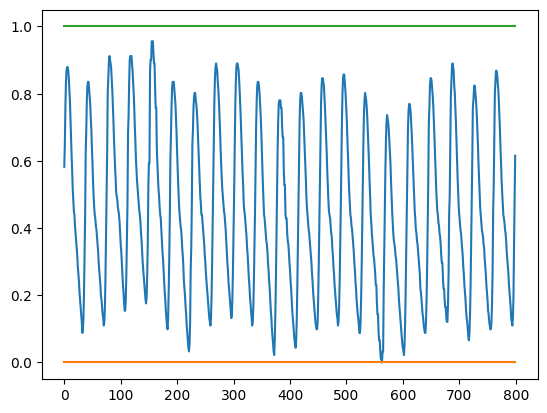

1.0


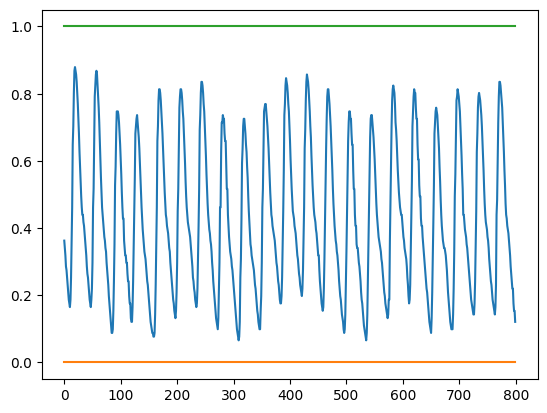

1.0


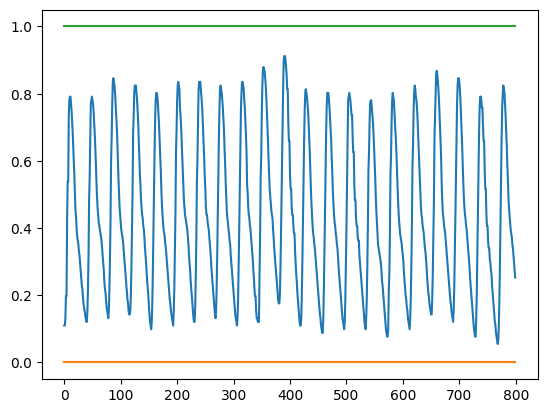

1.0


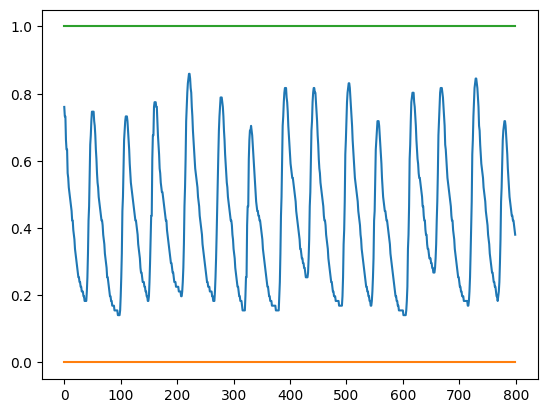

0.00125


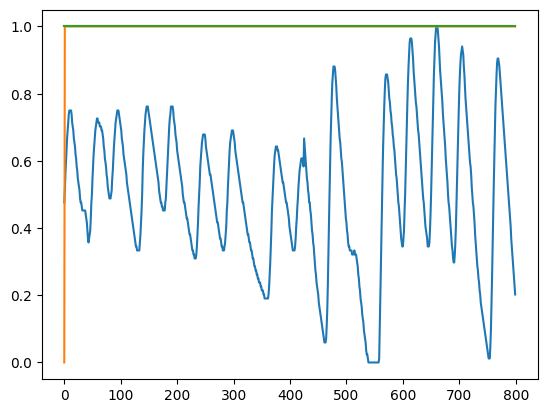

1.0


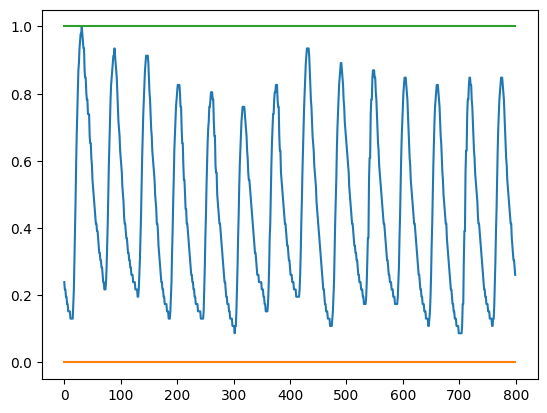

0.0


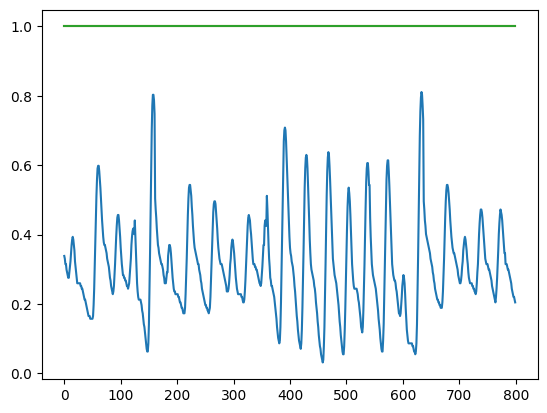

0.0


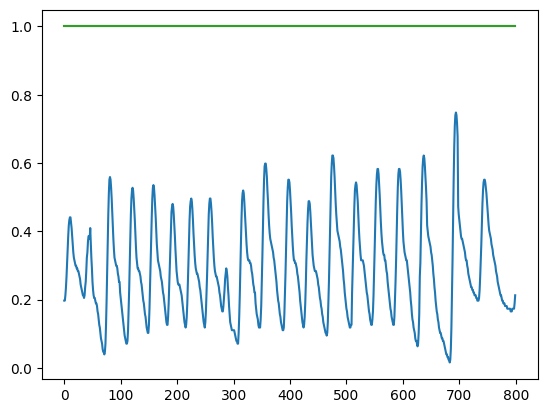

1.0


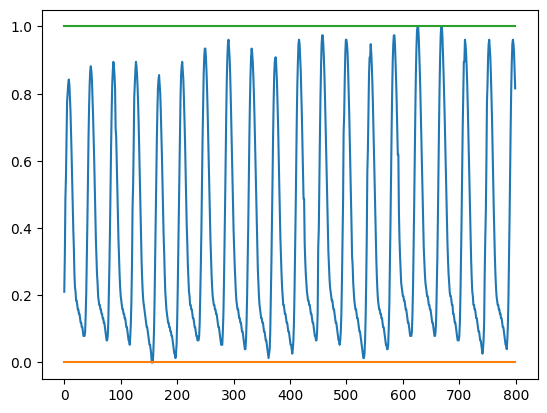

0.8675


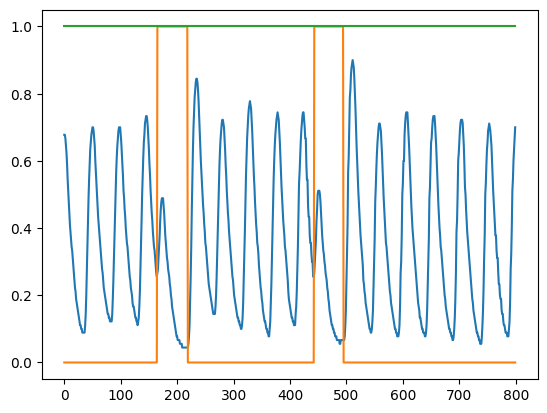

0.92249995


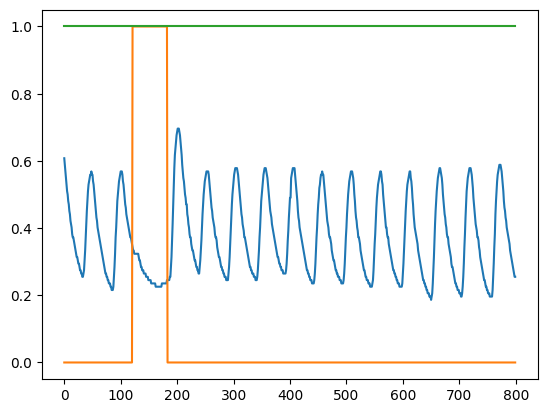

0.91625


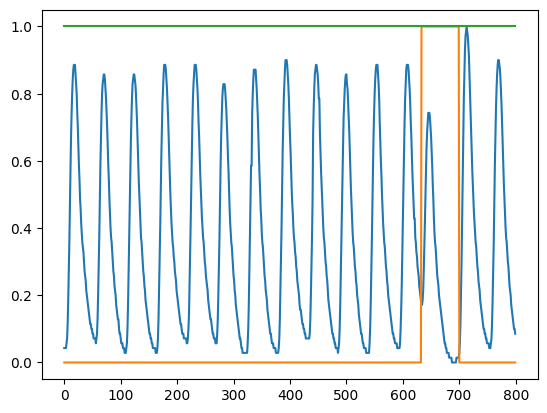

0.0


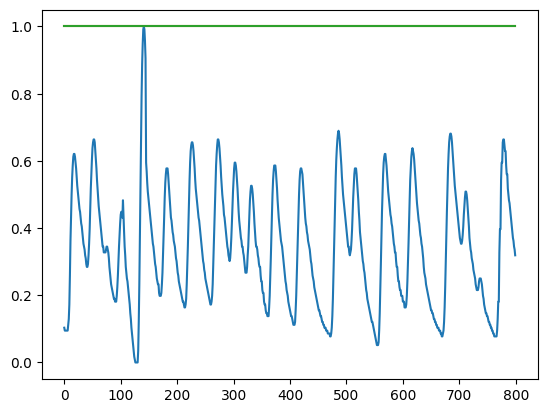

0.0


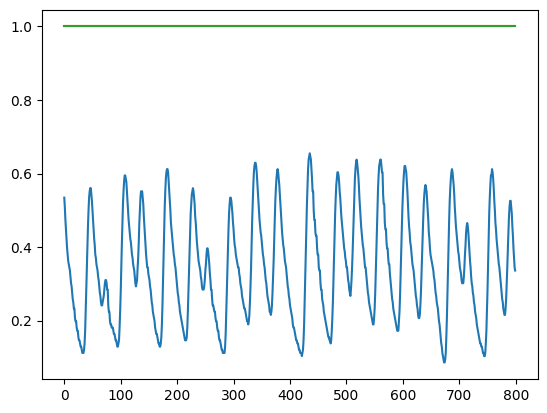

0.75874996


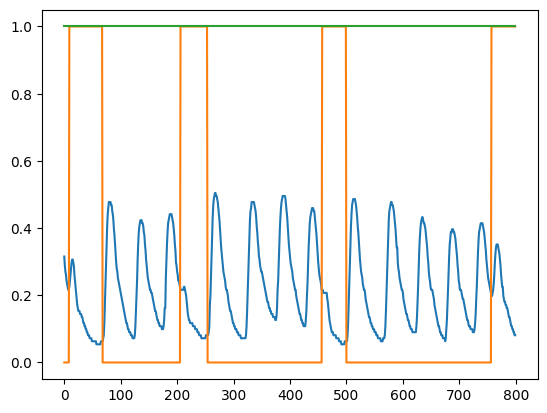

0.74


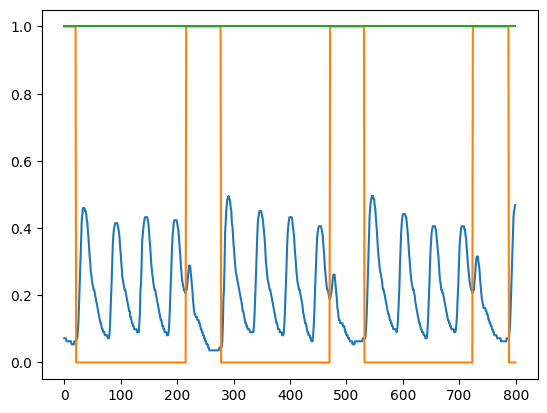

0.8275


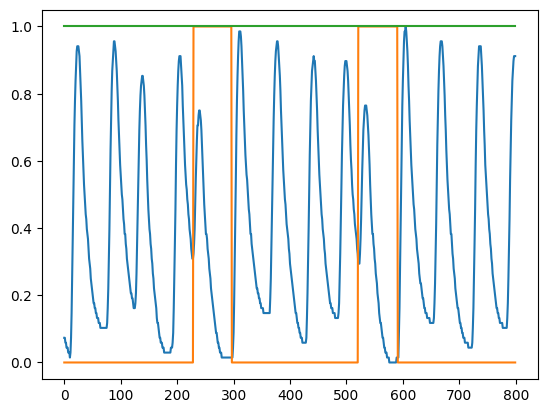

1.0


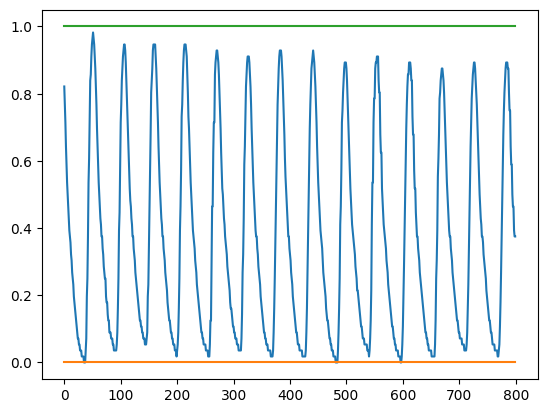

1.0


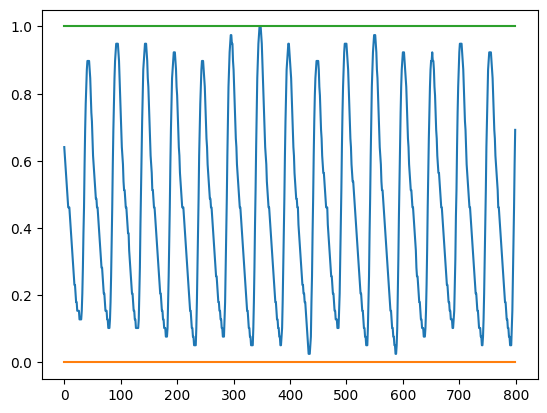

1.0


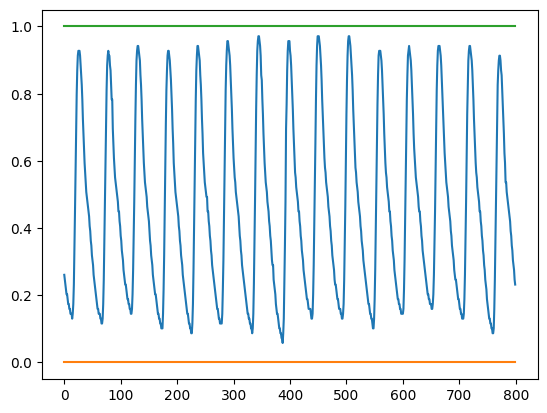

0.0


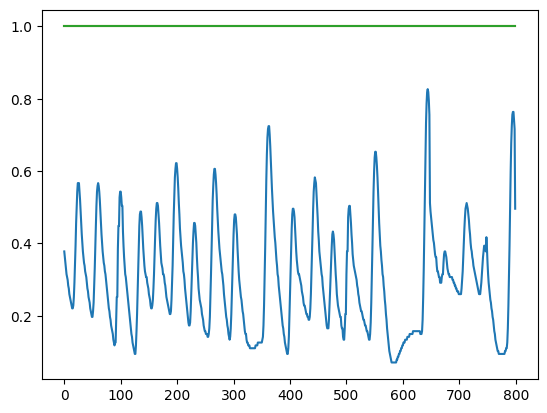

0.0


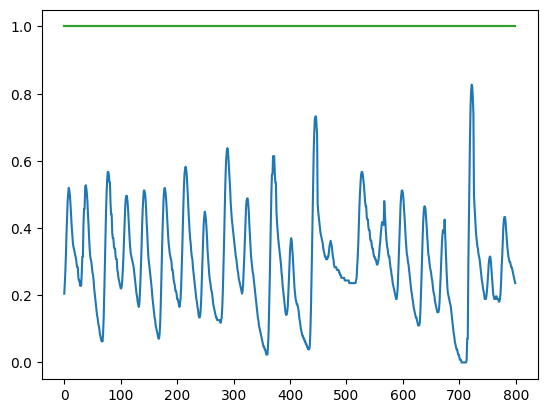

0.92625


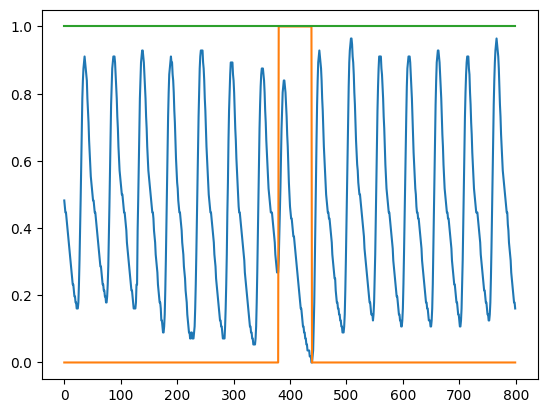

0.0


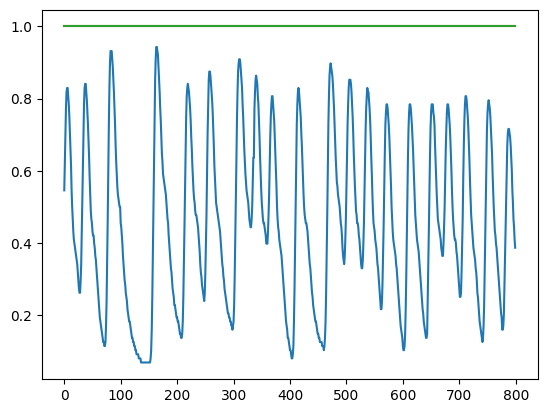

0.0


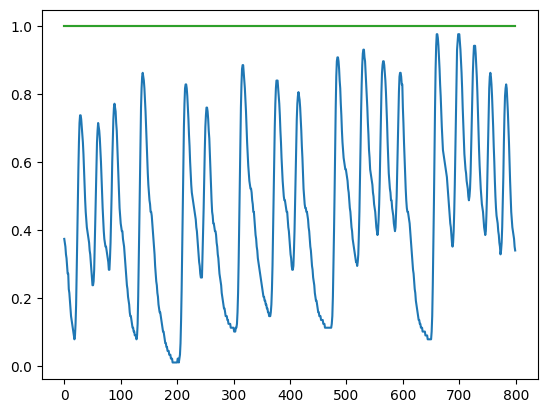

0.0


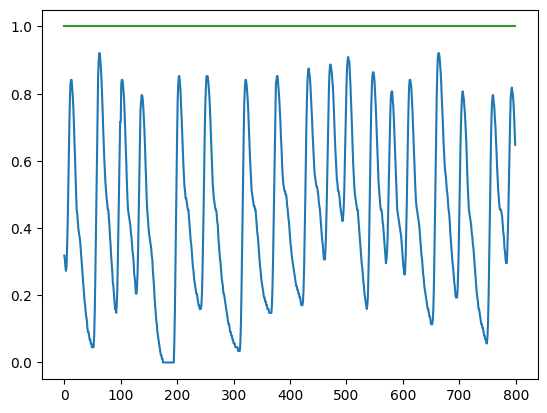

0.68125


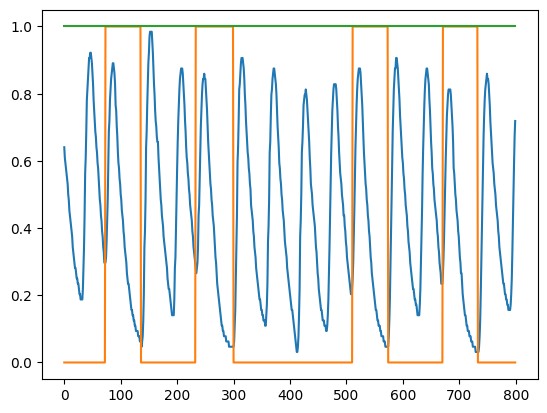

0.5125


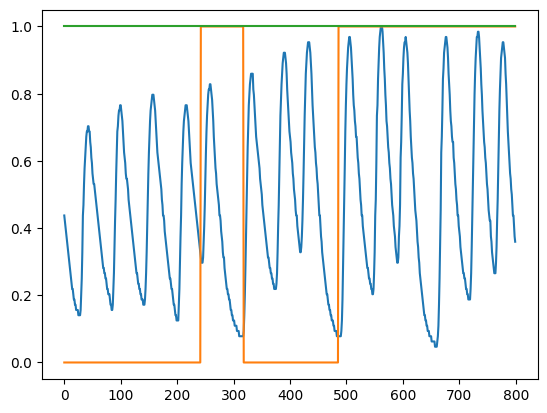

0.84


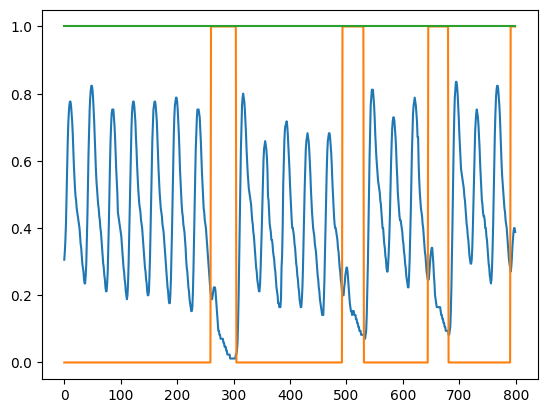

0.74


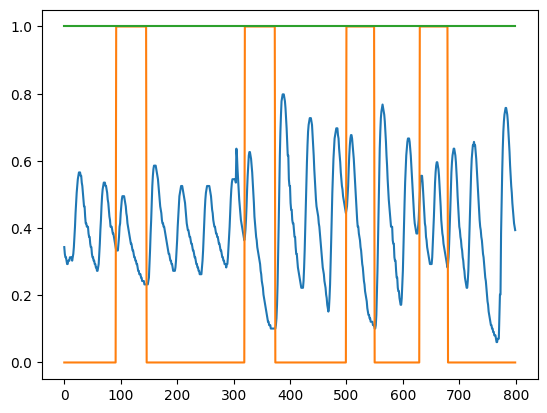

1.0


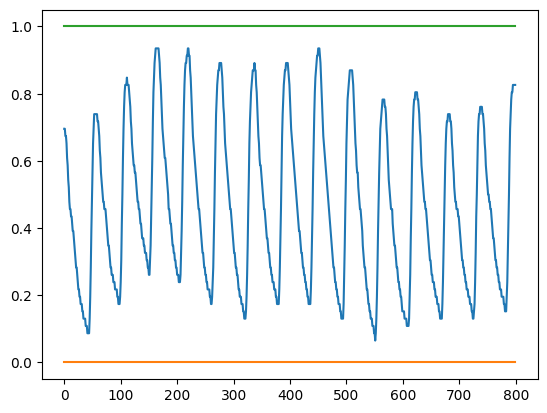

0.0


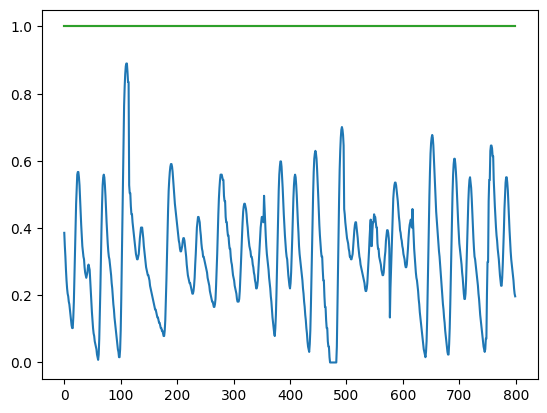

0.75124997


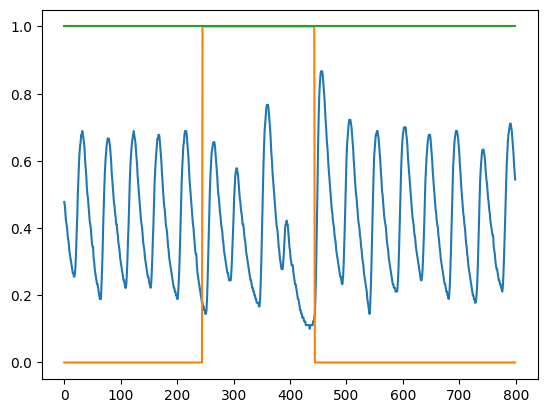

0.62


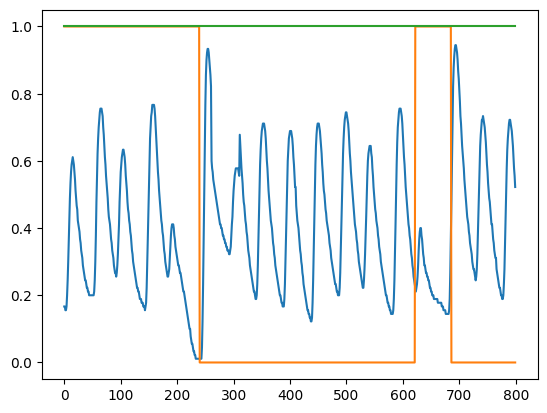

0.77125


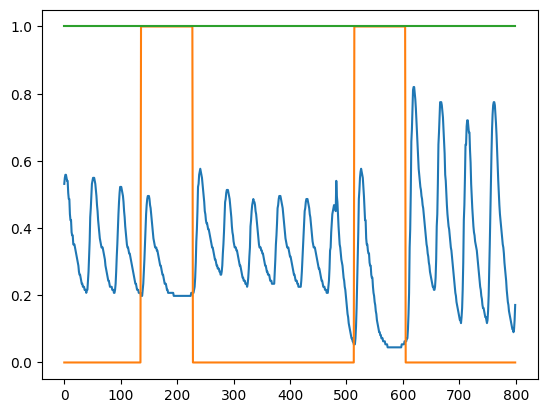

0.75874996


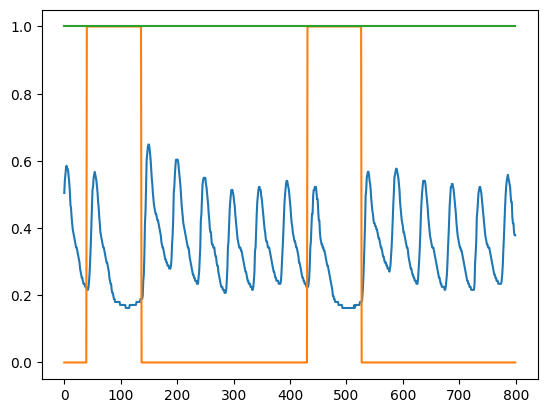

0.76


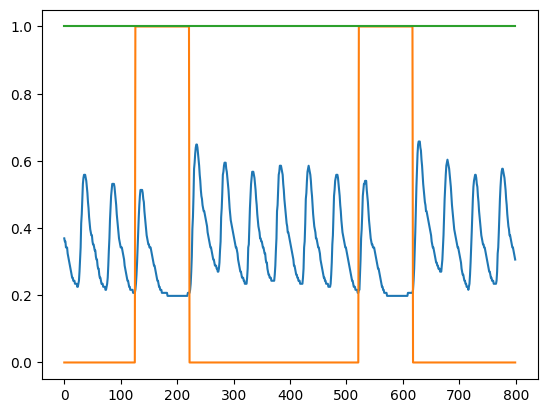

0.88124996


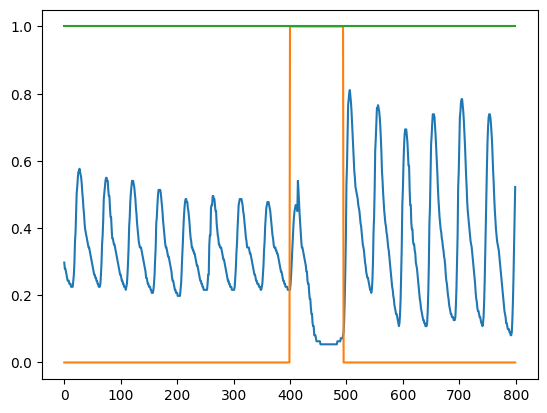

0.88124996


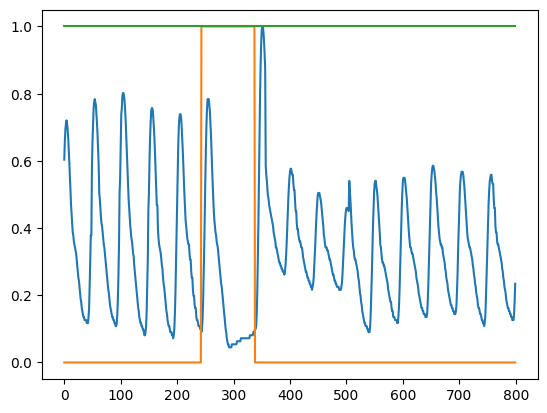

0.0


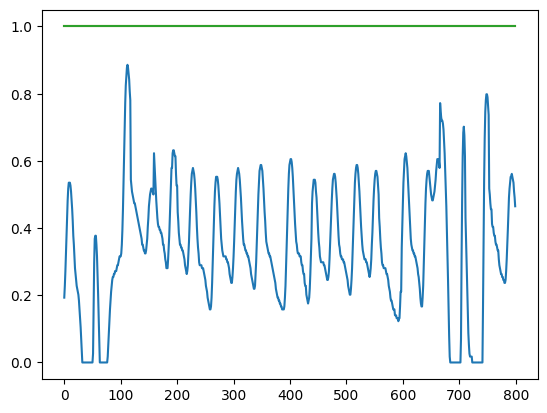

0.0


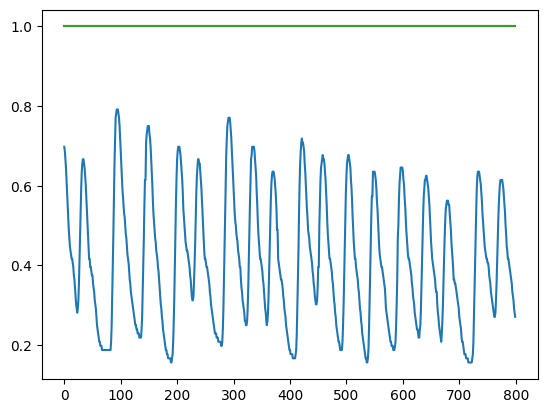

0.0


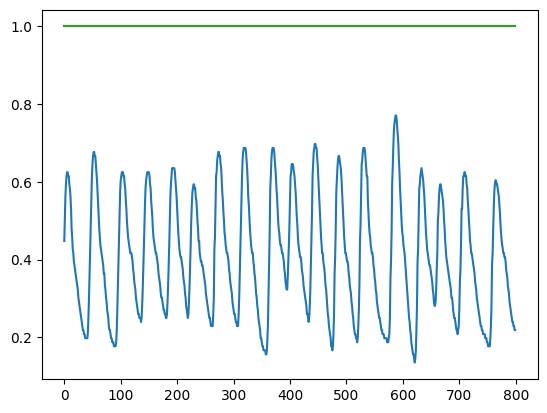

0.0


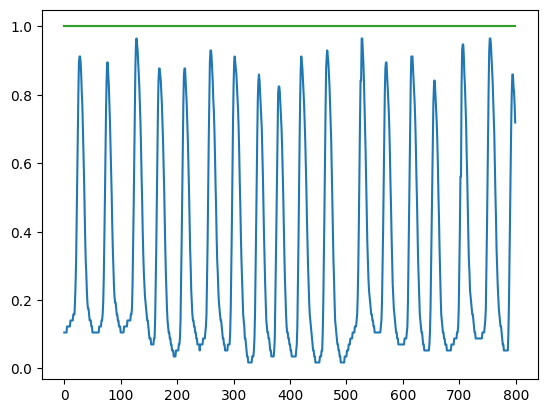

0.39249998


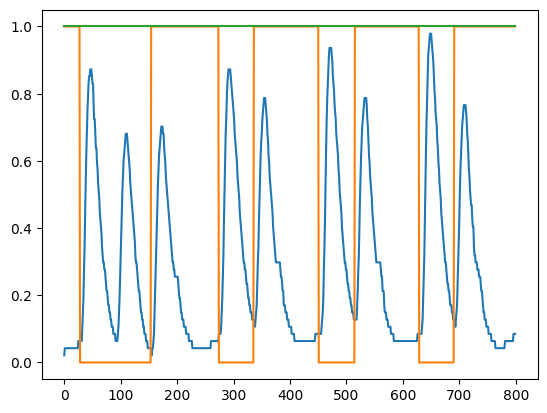

0.84125


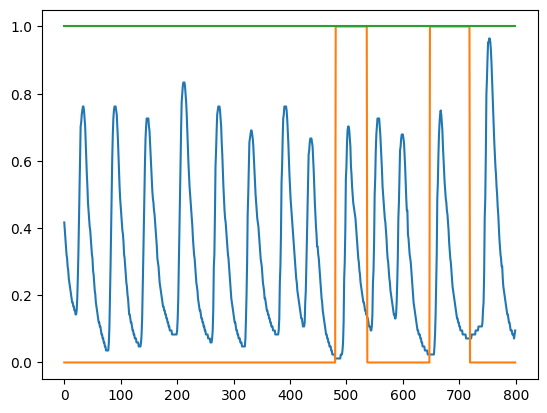

0.0


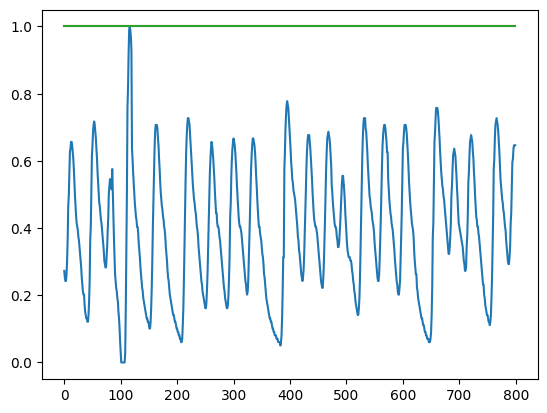

0.0


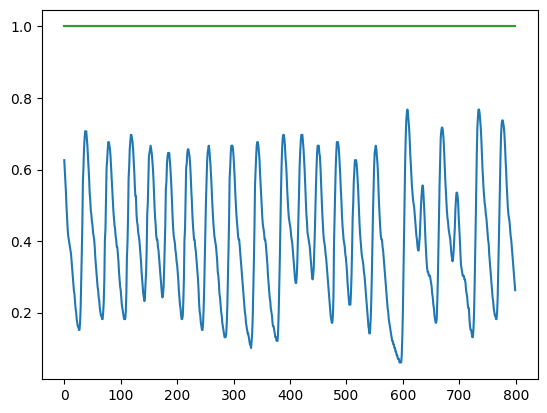

0.87375


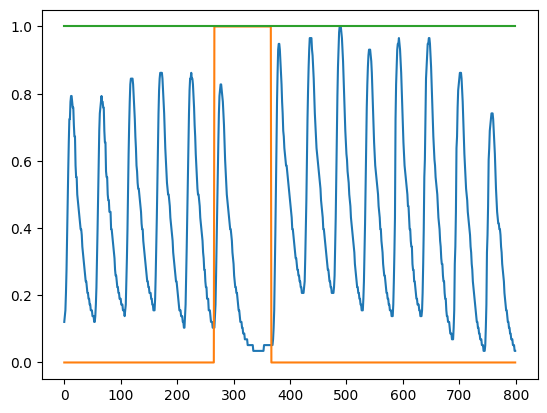

0.73125


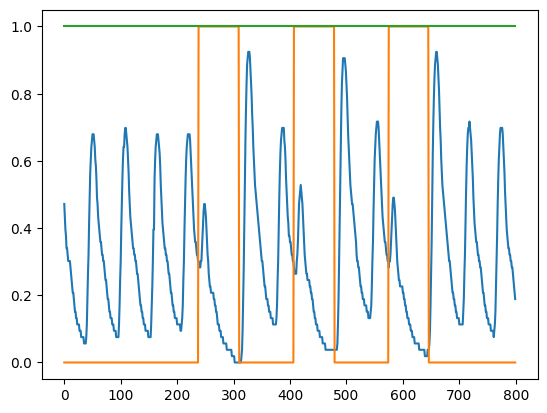

In [22]:
shower = performance()
test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")
shower.test(model,device,test_data,per_fnc = "series")
criterion = nn.L1Loss()
for i in range(len(test_data)):
    output = torch.stack([test_data[i][1]]).to(device)
    input = torch.stack([test_data[i][0]]).to(device)
    y_hat = model.forward(input)
    loss = criterion(y_hat,output)
    # if loss.cpu().detach().numpy()<0.3:
    print(loss.cpu().detach().numpy())
    plt.plot(input.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(output.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(y_hat.cpu().detach().numpy().flatten()[0:1000])
    plt.show()